In [1]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

class AgentType(Enum):
    PASSIVE = 1
    NORMAL = 2
    AGGRESSIVE = 3

TYPE_COEFFICIENTS = {
    AgentType.PASSIVE: 0.3,
    AgentType.NORMAL: 0.7,
    AgentType.AGGRESSIVE: 1.0
}

print("Imports successful!")
print(f"Mesa version: {mesa.__version__}")
print("V8 Step Budget Experiment: READY")

Imports successful!
Mesa version: 3.5.1
V8 Step Budget Experiment: READY


In [2]:
class QueueAgent(mesa.Agent):
    def __init__(self, model, agent_type):
        super().__init__(model)
        self.agent_type = agent_type
        self.type_coeff = TYPE_COEFFICIENTS[agent_type]
        self.urgency = np.random.uniform(0.3, 1.0)
        self.social_inhibition = np.random.uniform(0.2, 0.8)
        self.exited = False
        self.entry_time = None
        self.latency = None

    @property
    def behavior_score(self):
        base_score = (self.type_coeff * self.urgency /
                     self.social_inhibition)
        if self.pos:
            neighbors = self.model.grid.get_neighbors(
                self.pos,
                moore=True,
                include_center=False,
                radius=2
            )
            density_factor = 1.0 + (len(neighbors) * 0.05)
        else:
            density_factor = 1.0
        return base_score * density_factor

    def step(self):
        if self.exited:
            return
        if self.pos is None:
            return
        if self.entry_time is None:
            self.entry_time = self.model.steps

        x, y = self.pos
        move_prob = min(self.behavior_score, 1.0)

        if np.random.random() < move_prob:
            new_y = y - 1
            if new_y < 0:
                self.model.grid.remove_agent(self)
                self.exited = True
                if self.entry_time is not None:
                    self.latency = (self.model.steps -
                                   self.entry_time)
                self.model.exited_count += 1
                if self.latency is not None:
                    self.model.all_latencies.append(
                        self.latency
                    )
                return

            new_pos = (x, new_y)
            cell_contents = self.model.grid.get_cell_list_contents(
                [new_pos]
            )
            max_occupancy = (
                3 if self.agent_type == AgentType.AGGRESSIVE
                else 2 if self.agent_type == AgentType.NORMAL
                else 1
            )
            if len(cell_contents) < max_occupancy:
                self.model.grid.move_agent(self, new_pos)


class BunchQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30,
                 pct_aggressive=0.15, pct_normal=0.25):
        super().__init__()
        self.width = width
        self.height = height
        self.steps = 0
        self.exited_count = 0
        self.all_latencies = []
        self.total_agents = n_agents
        self.grid = mesa.space.MultiGrid(
            width, height, torus=False
        )
        n_aggressive = int(n_agents * pct_aggressive)
        n_normal = int(n_agents * pct_normal)
        n_passive = n_agents - n_aggressive - n_normal
        agent_types = (
            [AgentType.AGGRESSIVE] * n_aggressive +
            [AgentType.NORMAL] * n_normal +
            [AgentType.PASSIVE] * n_passive
        )
        np.random.shuffle(agent_types)
        for agent_type in agent_types:
            agent = QueueAgent(self, agent_type)
            x = np.random.randint(0, width)
            y = np.random.randint(height // 2, height)
            self.grid.place_agent(agent, (x, y))

    def step(self):
        self.steps += 1
        self.agents.shuffle_do("step")

    def run(self, max_steps=500):
        for _ in range(max_steps):
            self.step()
            if self.exited_count >= self.total_agents:
                break
        return self.exited_count

print("Agent and Model classes defined!")
print("Ready for step budget experiment")

Agent and Model classes defined!
Ready for step budget experiment


In [3]:
# STEP BUDGET EXPERIMENT
# Does optimal aggression shift as step budget increases?

print("V8 STEP BUDGET EXPERIMENT")
print("="*60)
print("Testing optimal aggression at each step budget")
print("="*60)

step_budgets = [200, 500, 1000, 2000, 5000]
aggression_levels = [i/100 for i in range(2, 82, 2)]
n_runs = 20
n_agents = 100

budget_results = {}

for budget in step_budgets:
    print(f"\nStep Budget: {budget}")
    print("-"*60)
    
    budget_data = []
    
    for pct_agg in aggression_levels:
        run_exited = []
        run_steps = []
        run_latencies = []
        
        for run in range(n_runs):
            model = BunchQueueModel(
                n_agents=n_agents,
                width=20,
                height=30,
                pct_aggressive=pct_agg,
                pct_normal=0.25
            )
            exited = model.run(max_steps=budget)
            run_exited.append(exited)
            run_steps.append(model.steps)
            if model.all_latencies:
                run_latencies.extend(model.all_latencies)
        
        avg_exited = np.mean(run_exited)
        avg_steps = np.mean(run_steps)
        pct_cleared = avg_exited / n_agents * 100
        avg_latency = (np.mean(run_latencies)
                      if run_latencies else 0)
        
        budget_data.append({
            'pct_aggressive': pct_agg,
            'avg_exited': avg_exited,
            'pct_cleared': pct_cleared,
            'avg_steps': avg_steps,
            'avg_latency': avg_latency
        })
        
        print(f"  {pct_agg*100:4.0f}% — "
              f"cleared: {pct_cleared:5.1f}% "
              f"steps: {avg_steps:.1f} "
              f"latency: {avg_latency:.1f}")
    
    # Find optimal for this budget
    # Optimal = highest clearance, then fastest steps
    optimal = max(budget_data,
                 key=lambda x: (x['pct_cleared'],
                               -x['avg_steps']))
    
    budget_results[budget] = {
        'data': budget_data,
        'optimal_aggr': optimal['pct_aggressive'],
        'optimal_cleared': optimal['pct_cleared'],
        'optimal_steps': optimal['avg_steps']
    }
    
    print(f"\n  OPTIMAL for budget {budget}: "
          f"{optimal['pct_aggressive']*100:.0f}% aggressive "
          f"— {optimal['pct_cleared']:.1f}% cleared "
          f"in {optimal['avg_steps']:.1f} steps")

# Summary table
print("\n" + "="*60)
print("STEP BUDGET SUMMARY")
print("="*60)
print(f"{'Budget':<10} {'Optimal %':<12} "
      f"{'Cleared':<10} {'Steps'}")
print("-"*60)

for budget, r in budget_results.items():
    print(f"{budget:<10} "
          f"{r['optimal_aggr']*100:.0f}%"
          f"{'':8} "
          f"{r['optimal_cleared']:.1f}%"
          f"{'':4} "
          f"{r['optimal_steps']:.1f}")

print("="*60)
print("\nDoes optimal aggression shift with step budget?")
optvals = [r['optimal_aggr']*100 
           for r in budget_results.values()]
if max(optvals) - min(optvals) > 10:
    print("YES — significant shift detected")
else:
    print("NO — optimal aggression is stable across budgets")
print("="*60)

V8 STEP BUDGET EXPERIMENT
Testing optimal aggression at each step budget

Step Budget: 200
------------------------------------------------------------
     2% — cleared:  99.2% steps: 374.6 latency: 126.9
     4% — cleared:  99.2% steps: 362.1 latency: 119.7
     6% — cleared:  99.1% steps: 368.2 latency: 119.0
     8% — cleared:  99.2% steps: 382.4 latency: 114.6
    10% — cleared:  99.3% steps: 381.5 latency: 114.8
    12% — cleared:  98.9% steps: 369.3 latency: 106.6
    14% — cleared:  99.5% steps: 366.3 latency: 105.9
    16% — cleared:  99.5% steps: 360.9 latency: 105.6
    18% — cleared:  99.2% steps: 361.1 latency: 104.9
    20% — cleared:  99.3% steps: 357.6 latency: 103.7
    22% — cleared:  99.5% steps: 370.7 latency: 100.7
    24% — cleared:  99.5% steps: 357.7 latency: 95.9
    26% — cleared:  99.5% steps: 356.2 latency: 94.9
    28% — cleared:  99.8% steps: 354.4 latency: 94.6
    30% — cleared:  99.4% steps: 354.2 latency: 90.9
    32% — cleared:  99.6% steps: 349.6 lat

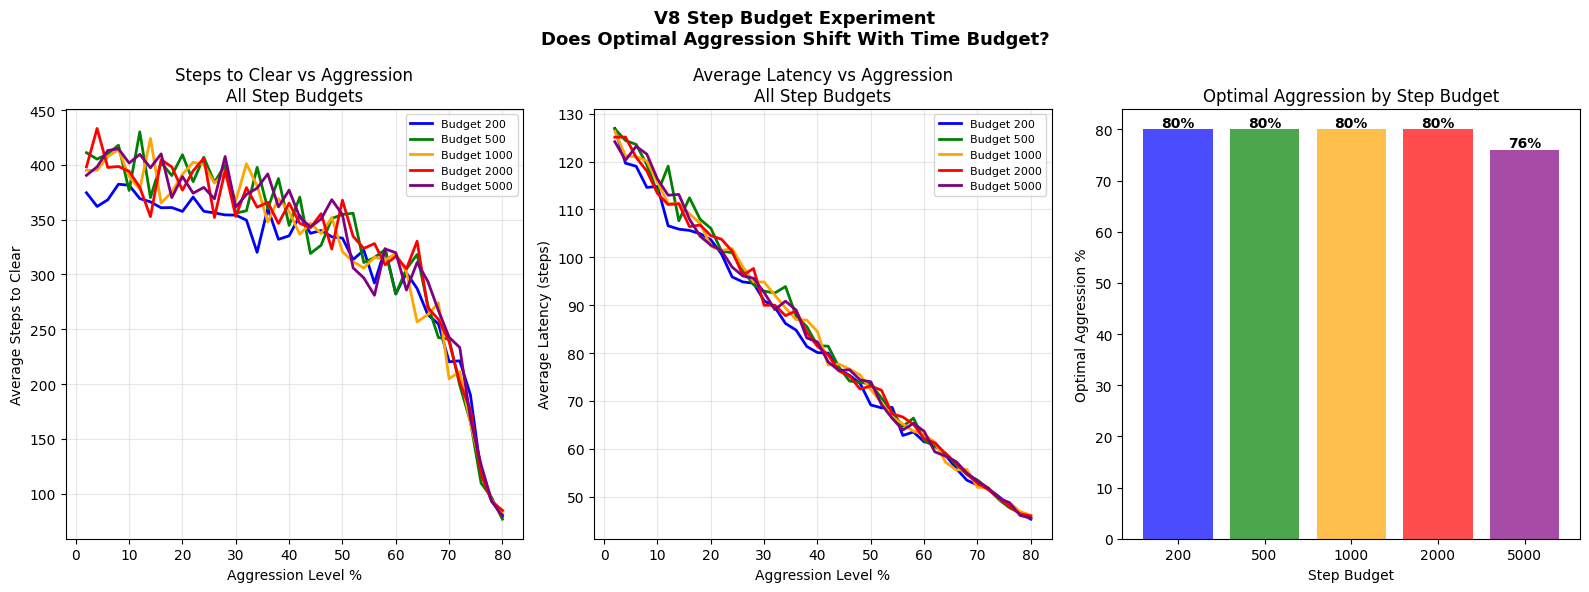

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colors = ['blue', 'green', 'orange', 'red', 'purple']
budgets = list(budget_results.keys())

# Chart 1 - Steps to clear vs aggression level
for i, budget in enumerate(budgets):
    data = budget_results[budget]['data']
    agg_levels = [d['pct_aggressive']*100 for d in data]
    steps = [d['avg_steps'] for d in data]
    axes[0].plot(agg_levels, steps,
                color=colors[i],
                linewidth=2,
                label=f'Budget {budget}')

axes[0].set_title('Steps to Clear vs Aggression\nAll Step Budgets')
axes[0].set_xlabel('Aggression Level %')
axes[0].set_ylabel('Average Steps to Clear')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Chart 2 - Latency vs aggression level
for i, budget in enumerate(budgets):
    data = budget_results[budget]['data']
    agg_levels = [d['pct_aggressive']*100 for d in data]
    latencies = [d['avg_latency'] for d in data]
    axes[1].plot(agg_levels, latencies,
                color=colors[i],
                linewidth=2,
                label=f'Budget {budget}')

axes[1].set_title('Average Latency vs Aggression\nAll Step Budgets')
axes[1].set_xlabel('Aggression Level %')
axes[1].set_ylabel('Average Latency (steps)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Chart 3 - Optimal aggression by budget
optimal_agg = [budget_results[b]['optimal_aggr']*100
               for b in budgets]
optimal_steps = [budget_results[b]['optimal_steps']
                for b in budgets]

ax3 = axes[2]
bars = ax3.bar(range(len(budgets)), optimal_agg,
               color=colors, alpha=0.7)
ax3.set_title('Optimal Aggression by Step Budget')
ax3.set_xlabel('Step Budget')
ax3.set_ylabel('Optimal Aggression %')
ax3.set_xticks(range(len(budgets)))
ax3.set_xticklabels([str(b) for b in budgets])
for bar, v in zip(bars, optimal_agg):
    ax3.text(bar.get_x() + bar.get_width()/2,
             v + 0.5, f'{v:.0f}%',
             ha='center', fontweight='bold')

plt.suptitle(
    'V8 Step Budget Experiment\n'
    'Does Optimal Aggression Shift With Time Budget?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/home/jc/v8_step_budget.png', dpi=150)
plt.show()
print("Chart saved!")